   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03

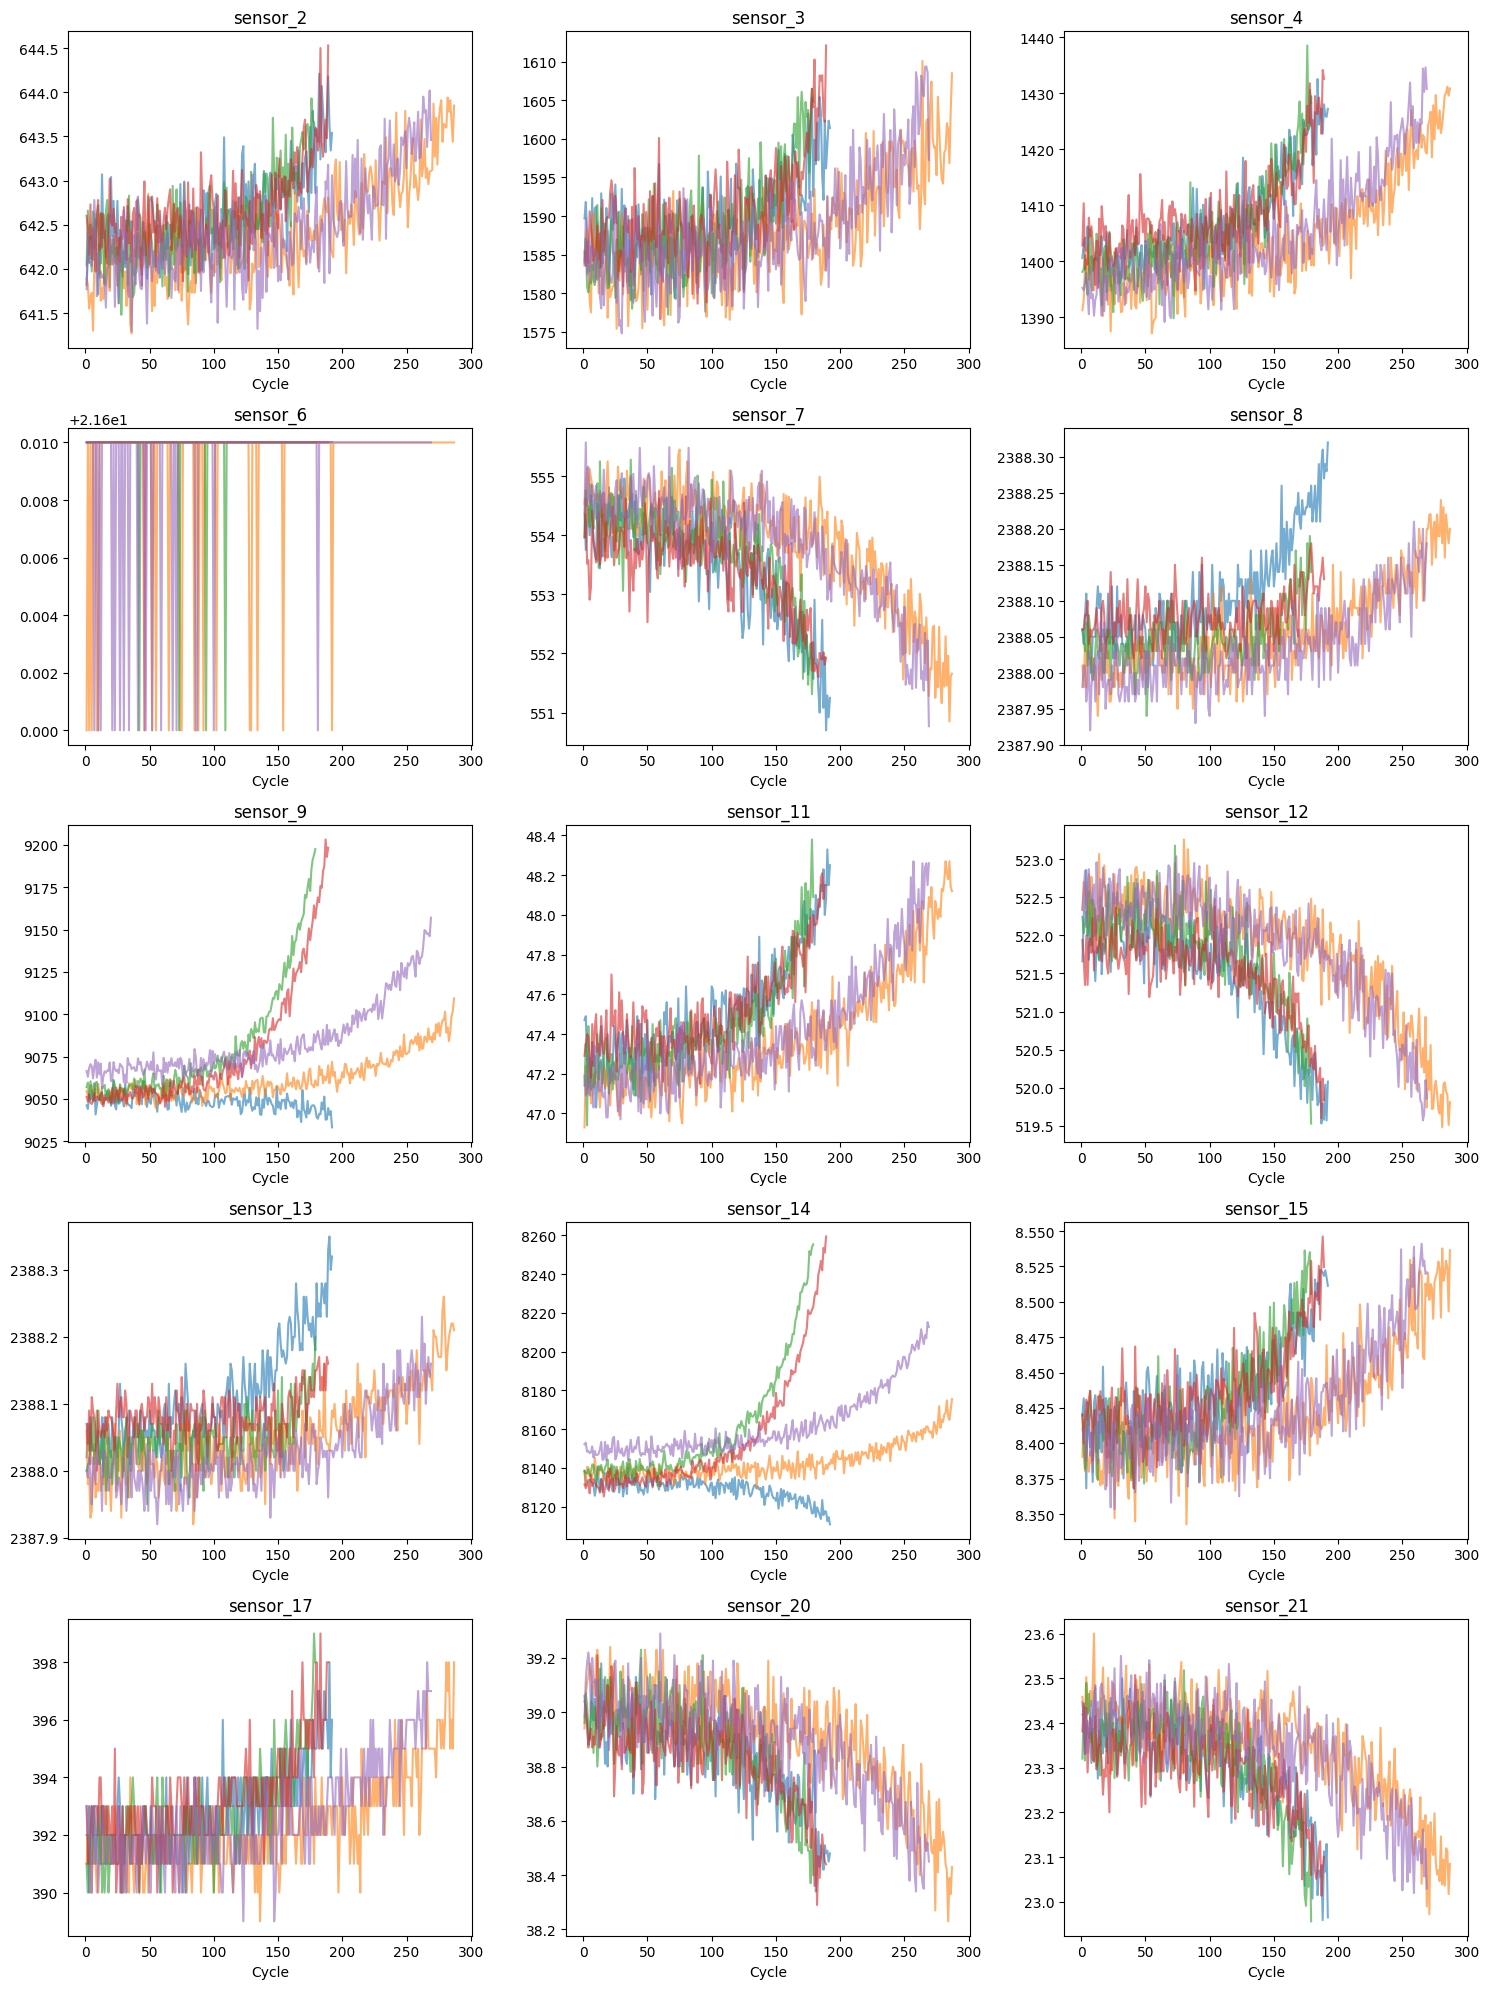

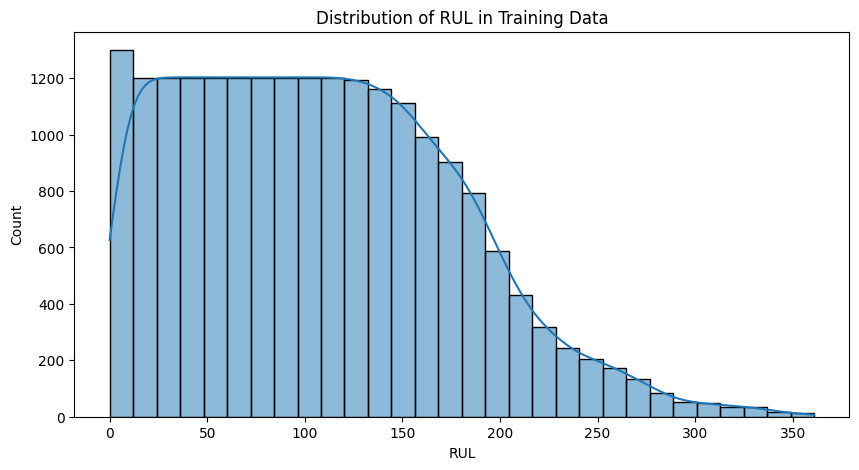

engine_id
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64


In [ ]:
# Importing necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
# Importing the dataset, data set has no header, so we will add it manually
column_names = ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3',
                'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
                'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
                'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
                'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
                'sensor_21']
Data_raw=Path('..') / 'data' / 'raw'
train_df = pd.read_csv(Data_raw / 'train_FD001.txt', sep='\s+', header=None, names=column_names)
test_df = pd.read_csv(Data_raw / 'test_FD001.txt', sep='\s+', header=None, names=column_names)
rul_df = pd.read_csv(Data_raw / 'RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])
# Elementary ispection of the data, first 5 rows
print(train_df.head())
print(test_df.head())
print(rul_df.head())
# Basic statistics of the data
print(train_df.describe())
print(train_df.isnull().sum())
print(test_df.describe())
print(test_df.isnull().sum())
# How many engines are in the training and test datasets?
print(f'Number of engines in training dataset: {train_df["engine_id"].nunique()}')
print(f'Number of engines in test dataset: {test_df["engine_id"].nunique()}')
# RUL consractions, calculate the RUL for train set
train_df['RUL'] = train_df.groupby('engine_id')['cycle'].transform(max) - train_df['cycle']
print(train_df.head())
# Analyzing sensor data, wich sensor are constant and which are variable? Variable sensors are more likely to be useful for predictive maintenance
constant_sensors = []
variable_sensors = []
for sensor in [f'sensor_{i}' for i in range(1, 22)]:
    if train_df[sensor].nunique() == 1:
        constant_sensors.append(sensor)
    else:
        variable_sensors.append(sensor)
print(f'Constant sensors: {constant_sensors}')
print(f'Variable sensors: {variable_sensors}')
# Visualazing degradation Plot sensor 1 vs RUL for a few engines
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15,20))
axes = axes.flatten()
for idx, sensor in enumerate(variable_sensors):
    for engine_id in range(1, 6):  # Plot for first 5 engines
        engine_data = train_df[train_df['engine_id'] == engine_id]
        axes[idx].plot(engine_data['cycle'], engine_data[sensor], alpha=0.6)
    axes[idx].set_title(sensor)
    axes[idx].set_xlabel('Cycle')

plt.tight_layout()
plt.show()
# Distribution of RUL histogram
plt.figure(figsize=(10, 5))
sns.histplot(train_df['RUL'], bins=30, kde=True)
plt.xlabel('RUL')
plt.title('Distribution of RUL in Training Data')
plt.show()
# Cycle per engine 
cycles_per_engine = train_df.groupby('engine_id')['cycle'].max()
print(cycles_per_engine)
# Adding informative sensors
informative_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
    'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14',
    'sensor_15', 'sensor_20', 'sensor_21'
]
